# 🧠 The Perceptron
**Course:** Deep Learning  
**Lecture:** 1 - The Perceptron  
**Part:** a - Neuron Math

---

> **Where we are:** Before we build networks, we need to understand what a single neuron computes.

**What you'll learn:**
- What a neuron computes: $z = \mathbf{w}^T \mathbf{x} + b$, then $a = f(z)$
- The dot product as a weighted sum - implement it 3 ways
- Bias: why it matters (geometrically)
- The activation function role
- Vector/matrix shape conventions

**Exam relevance:** ⭐⭐⭐ (Crucial for understanding all further architectures in the course)

In [9]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Confirm device
print(f"TensorFlow {tf.__version__} | Devices: {[d.name for d in tf.config.list_physical_devices()]}")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

TensorFlow 2.20.0 | Devices: ['/physical_device:CPU:0']


## 📖 Theory: What a neuron computes

A single artificial neuron performs two fundamental operations:
1. **Weighted Sum (Linear):** $z = \sum_{i=1}^n w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$
2. **Activation (Non-linear):** $a = f(z)$

- $\mathbf{x}$: Input vector
- $\mathbf{w}$: Weight vector (determines importance of each input)
- $b$: Bias (shifts the decision boundary)
- $f$: Activation function (e.g., step function, sigmoid)

## 🔀 Your Options: The Dot Product

At this step, you can choose between: A, B, or C

| Option | Implementation | Pros | Cons | When to use |
|---|---|---|---|---|
| A | `for` loop | Easy to understand | Extremely slow | Never in practice |
| B | `np.dot` | Fast, optimized C code | Runs on CPU only | Traditional ML / Prep |
| C | `tf.matmul` | Hardware accelerated (GPU/TPU) | Slight overhead | Deep Learning |

In [10]:
# 1. Python loop implementation
def neuron_loop(x, w, b, activation=None):
    z = sum(xi * wi for xi, wi in zip(x, w)) + b
    return activation(z) if activation else z

# 2. NumPy dot product
def neuron_numpy(x, w, b, activation=None):
    z = np.dot(w, x) + b
    return activation(z) if activation else z

# 3. TensorFlow matmul
def neuron_tf(x, w, b, activation=None):
    x_t = tf.constant(x, dtype=tf.float32)
    w_t = tf.constant(w, dtype=tf.float32)
    b_t = tf.constant([b], dtype=tf.float32)
    z = tf.linalg.matvec(tf.reshape(w_t, (1, -1)), x_t) + b_t
    z = float(z.numpy()[0])
    return activation(z) if activation else z

# Test
w = [0.5, -0.3]
x = [1.0, 2.0]
b = 0.1
z_loop = neuron_loop(x, w, b)
z_np = neuron_numpy(np.array(x), np.array(w), b)
z_tf = neuron_tf(x, w, b)
print(f'Loop: {z_loop:.4f}, NumPy: {z_np:.4f}, TF: {z_tf:.4f}')
assert abs(z_loop - z_np) < 1e-6 and abs(z_np - z_tf) < 1e-6, 'Values must match!'
print('All three implementations match!')

In [11]:
# ✅ Solution

def neuron_loop_sol(x, w, b):
    z = b
    for i in range(len(x)):
        z += x[i] * w[i]
    return z

def neuron_numpy_sol(x, w, b):
    x_np = np.array(x)
    w_np = np.array(w)
    return np.dot(w_np, x_np) + b

def neuron_tf_sol(x, w, b):
    x_tf = tf.constant(x, dtype=tf.float32)
    w_tf = tf.constant(w, dtype=tf.float32)
    # tf.tensordot is equivalent to np.dot for 1D tensors
    return tf.tensordot(w_tf, x_tf, axes=1) + b

In [12]:
# 🔬 Comparison: Checking all implementations

val_loop = neuron_loop_sol(x, w, b)
val_np = neuron_numpy_sol(x, w, b)
val_tf = neuron_tf_sol(x, w, b).numpy()

print(f"Loop result:  {val_loop:.4f}")
print(f"NumPy result: {val_np:.4f}")
print(f"TF result:    {val_tf:.4f}")

assert np.isclose(val_loop, val_np, atol=1e-5) and np.isclose(val_np, val_tf, atol=1e-5), "Results do not match!"
print("All implementations yield the same result!")

Loop result:  -0.5500
NumPy result: -0.5500
TF result:    -0.5500
All implementations yield the same result!


## 📖 Theory: Bias and Geometric Interpretation

Without a bias $b$, the decision boundary $\mathbf{w}^T \mathbf{x} = 0$ is forced to pass through the origin $(0,0)$.
The bias $b$ allows the boundary to translate, giving the neuron the ability to separate classes that aren't centered at the origin.

In [13]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    {'w': [1, 1], 'b': 0, 'title': 'w=[1,1], b=0'},
    {'w': [2, -1], 'b': 0, 'title': 'w=[2,-1], b=0 (rotated)'},
    {'w': [1, 1], 'b': -1, 'title': 'w=[1,1], b=-1 (shifted)'},
]
for ax, cfg in zip(axes, configs):
    w1, w2 = cfg['w']
    b = cfg['b']
    z = w1 * xx + w2 * yy + b
    # Decision boundary is where z=0
    ax.contourf(xx, yy, z, levels=[-10, 0, 10], colors=['#4a90d9', '#e74c3c'], alpha=0.4)
    ax.contour(xx, yy, z, levels=[0], colors='white', linewidths=2)
    ax.set_title(cfg['title'])
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.suptitle('Decision boundaries for different weights and biases')
plt.tight_layout()
plt.show()

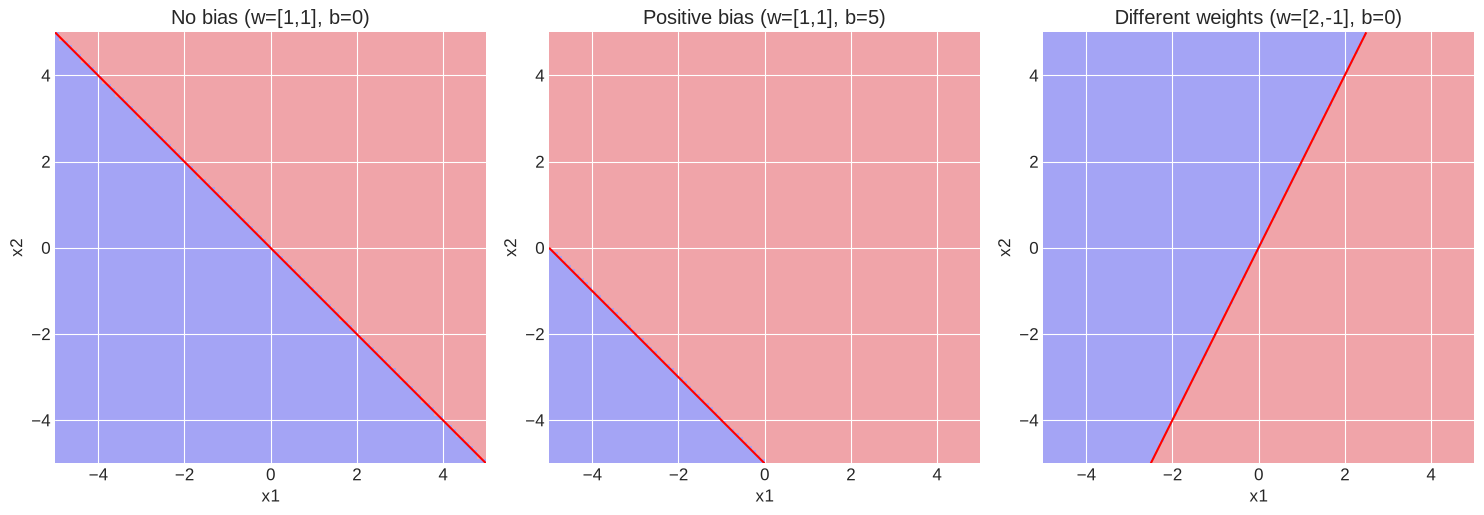

In [14]:
# ✅ Solution & 🔬 Comparison

# Create a grid
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

def plot_decision_boundary(ax, w1, w2, b, title):
    Z = w1 * X1 + w2 * X2 + b
    # Contour at Z=0 is the decision boundary
    ax.contour(X1, X2, Z, levels=[0], colors='red')
    ax.imshow(Z > 0, extent=[-5, 5, -5, 5], origin='lower', alpha=0.3, cmap='bwr')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Comparison 1: No bias
plot_decision_boundary(axs[0], 1, 1, 0, "No bias (w=[1,1], b=0)")

# Comparison 2: Positive bias
plot_decision_boundary(axs[1], 1, 1, 5, "Positive bias (w=[1,1], b=5)")

# Comparison 3: Different weights
plot_decision_boundary(axs[2], 2, -1, 0, "Different weights (w=[2,-1], b=0)")

plt.tight_layout()
plt.show()

## 🎓 Exam Corner

### Question 1 (Conceptual)
What does the bias term do geometrically?

<details><summary>💡 Answer</summary>

The bias shifts the decision boundary ($\mathbf{w}^T \mathbf{x} + b = 0$) away from the origin. Without a bias, the hyperplane must pass through the origin, severely limiting the functions the neuron can represent.
</details>

### Question 2 (Practical)
What is the output of a neuron with weights [0.5, -0.3], bias 0.1, input [1, 2], and sigmoid activation? Let sigmoid be $\sigma(z) = \frac{1}{1 + e^{-z}}$.

<details><summary>💡 Answer</summary>

1. Compute $z = (0.5 \times 1) + (-0.3 \times 2) + 0.1 = 0.5 - 0.6 + 0.1 = 0.0$
2. Apply activation: $\sigma(0.0) = \frac{1}{1 + 1} = 0.5$
</details>

### Question 3 (Conceptual)
Why can't a single neuron solve XOR?

<details><summary>💡 Answer</summary>

A single neuron represents a single linear decision boundary (a hyperplane). The XOR problem is not linearly separable, meaning no single straight line can separate the positive classes from the negative classes.
</details>